#Install Dependencies

In [2]:
!pip install -q sentence-transformers

#Imports

In [3]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random

from scipy.sparse import coo_matrix, hstack, vstack
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# Mount Drive

In [4]:
from google.colab import drive
import os

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/slightgcn"
os.makedirs(base_path, exist_ok=True)

#Dataset

In [5]:
!wget https://mcauleylab.ucsd.edu/public_datasets/data/amazon_v2/categoryFilesSmall/Movies_and_TV_5.json.gz

--2026-03-17 06:30:38--  https://mcauleylab.ucsd.edu/public_datasets/data/amazon_v2/categoryFilesSmall/Movies_and_TV_5.json.gz
Resolving mcauleylab.ucsd.edu (mcauleylab.ucsd.edu)... 137.110.161.5
Connecting to mcauleylab.ucsd.edu (mcauleylab.ucsd.edu)|137.110.161.5|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791152395 (755M) [application/gzip]
Saving to: ‘Movies_and_TV_5.json.gz’

Movies_and_TV_5.jso 100%[===================>] 754.50M  40.3MB/s    in 18s     

2026-03-17 06:30:57 (41.6 MB/s) - ‘Movies_and_TV_5.json.gz’ saved [791152395/791152395]



#Load Reviews

In [6]:
dataset_cache = f"{base_path}/reviews_processed.pkl"

if os.path.exists(dataset_cache):

    print("Loading cached dataset...")
    reviews = pd.read_pickle(dataset_cache)

else:

    print("Processing dataset...")

    import gzip
    import json

    data=[]

    with gzip.open("Movies_and_TV_5.json.gz") as f:
        for i,line in enumerate(f):

            data.append(json.loads(line))

            if i==300000:
                break

    reviews=pd.DataFrame(data)

    reviews=reviews[[
        "reviewerID",
        "asin",
        "overall",
        "reviewText"
    ]]

    reviews.rename(columns={
        "reviewerID":"userId",
        "asin":"itemId",
        "overall":"rating"
    },inplace=True)

    reviews=reviews[reviews["rating"]>=4]

    reviews.to_pickle(dataset_cache)

    print("Dataset cached")

Loading cached dataset...


# Encode Users / Items

In [7]:
user_map = {u:i for i,u in enumerate(reviews["userId"].unique())}
item_map = {i:j for j,i in enumerate(reviews["itemId"].unique())}

reviews["userId"] = reviews["userId"].map(user_map)
reviews["itemId"] = reviews["itemId"].map(item_map)

n_users = len(user_map)
n_items = len(item_map)

print("Users:", n_users)
print("Items:", n_items)

Users: 113819
Items: 3886


# Train/Test Split

In [8]:
train_path = f"{base_path}/train.csv"
test_path = f"{base_path}/test.csv"

if os.path.exists(train_path) and os.path.exists(test_path):

    print("Loading cached train/test split")

    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)

else:

    print("Creating train/test split")

    train_list=[]
    test_list=[]

    for user in reviews["userId"].unique():

        user_data=reviews[reviews["userId"]==user]

        if len(user_data)<2:
            continue

        test_sample=user_data.sample(1, random_state=42)
        train_sample=user_data.drop(test_sample.index)

        train_list.append(train_sample)
        test_list.append(test_sample)

    train=pd.concat(train_list)
    test=pd.concat(test_list)

    train.to_csv(train_path,index=False)
    test.to_csv(test_path,index=False)

    print("Train/test split saved")

print("Train:",len(train))
print("Test:",len(test))

Loading cached train/test split
Train: 137666
Test: 47940


# Cold Items

In [9]:
# Cold Items
item_counts = train["itemId"].value_counts()
cold_items = set(item_counts[item_counts <= 5].index.tolist())
print("Cold items:", len(cold_items))

Cold items: 1151


# Build Interaction Graph

In [10]:
import os
from scipy.sparse import save_npz, load_npz

adj_path = f"{base_path}/adj_norm.npz"

if os.path.exists(adj_path):

    print("Loading cached adjacency matrix")

    adj_norm = load_npz(adj_path).tocoo()

else:

    print("Building adjacency matrix")

    rows = train["userId"].values
    cols = train["itemId"].values

    data = np.ones(len(rows))

    R = coo_matrix((data,(rows,cols)),shape=(n_users,n_items))

    upper = hstack([coo_matrix((n_users,n_users)),R])
    lower = hstack([R.T,coo_matrix((n_items,n_items))])

    adj = vstack([upper,lower]).tocoo()

    rowsum = np.array(adj.sum(1)).flatten()

    d_inv_sqrt = np.power(rowsum,-0.5)
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.

    D_inv_sqrt = coo_matrix(
        (d_inv_sqrt,(range(len(d_inv_sqrt)),range(len(d_inv_sqrt)))),
        shape=(adj.shape[0],adj.shape[0])
    )

    adj_norm = D_inv_sqrt.dot(adj).dot(D_inv_sqrt).tocoo()

    save_npz(adj_path, adj_norm)

    print("Adjacency matrix saved")

# convert to torch sparse
indices = torch.tensor([adj_norm.row, adj_norm.col], dtype=torch.long)
values = torch.tensor(adj_norm.data, dtype=torch.float32)

adj_norm_torch = torch.sparse.FloatTensor(
    indices,
    values,
    torch.Size(adj_norm.shape)
).to(device)

Loading cached adjacency matrix


/tmp/ipykernel_301/710413786.py:45: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  indices = torch.tensor([adj_norm.row, adj_norm.col], dtype=torch.long)
/tmp/ipykernel_301/710413786.py:48: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  adj_norm_torch = torch.sparse.FloatTensor(


# Extract Review Text Embeddings

In [11]:
text_path = f"{base_path}/text_matrix.npy"

if os.path.exists(text_path):

    print("Loading cached SBERT embeddings")

    text_matrix = np.load(text_path)

else:

    print("Generating SBERT embeddings")

    item_reviews = reviews.groupby("itemId")["reviewText"].apply(list)

    texts = []

    for r in item_reviews:

        cleaned = [str(x) for x in r if isinstance(x,str)]
        cleaned = cleaned[:5]

        texts.append(" ".join(cleaned))

    model_text = SentenceTransformer("all-MiniLM-L6-v2", device=device)

    item_text_emb = model_text.encode(
        texts,
        show_progress_bar=True
    )

    text_matrix = np.zeros((n_items,item_text_emb.shape[1]))

    for item_id,emb in zip(item_reviews.index,item_text_emb):
        text_matrix[item_id] = emb

    np.save(text_path,text_matrix)

    print("SBERT embeddings saved")

print(text_matrix.shape)

Loading cached SBERT embeddings
(3886, 384)


# Save Metadata

In [12]:
metadata = {
    "n_users": n_users,
    "n_items": n_items,
    "embedding_dim": 64,
    "layers": 3,
    "dataset_size": len(reviews)
}

import json

with open(f"{base_path}/metadata.json","w") as f:
    json.dump(metadata,f,indent=4)

# LightGCN Model

In [13]:
class LightGCN(nn.Module):

    def __init__(self,n_users,n_items,emb_dim,n_layers):

        super().__init__()

        self.n_users=n_users
        self.n_items=n_items
        self.n_layers=n_layers

        self.user_emb=nn.Embedding(n_users,emb_dim)
        self.item_emb=nn.Embedding(n_items,emb_dim)

        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

    def forward(self,adj):

        E0=torch.cat([self.user_emb.weight,self.item_emb.weight],dim=0)

        all_embeddings=[E0]
        E=E0

        for _ in range(self.n_layers):
          E = torch.sparse.mm(adj,E)
          E = nn.functional.dropout(E,p=0.1,training=self.training)
          all_embeddings.append(E)

        weights = [1/(self.n_layers+1)]*(self.n_layers+1)

        E_final = sum(
            w*emb for w,emb in zip(weights,all_embeddings)
        )

        users_final=E_final[:self.n_users]
        items_final=E_final[self.n_users:]

        return users_final,items_final

# Semantic LightGCN

In [14]:
class SLightGCN(nn.Module):

    def __init__(self,n_users,n_items,emb_dim,n_layers,text_emb,alpha=0.1):

        super().__init__()

        self.n_users=n_users
        self.n_items=n_items
        self.n_layers=n_layers
        self.alpha=alpha

        self.user_emb=nn.Embedding(n_users,emb_dim)
        self.item_emb=nn.Embedding(n_items,emb_dim)

        self.text_proj=nn.Linear(text_emb.shape[1],emb_dim,bias=False)

        self.register_buffer(
            "text_emb",
            torch.tensor(text_emb,dtype=torch.float32)
        )

        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

    def forward(self,adj):

        item_semantic=self.text_proj(self.text_emb)

        item_initial=self.item_emb.weight+self.alpha*item_semantic

        E0=torch.cat([self.user_emb.weight,item_initial],dim=0)

        all_embeddings=[E0]
        E=E0

        for _ in range(self.n_layers):
            E = torch.sparse.mm(adj,E)
            E = nn.functional.dropout(E,p=0.1,training=self.training)
            all_embeddings.append(E)

        weights = [1/(self.n_layers+1)]*(self.n_layers+1)

        E_final = sum(
            w*emb for w,emb in zip(weights,all_embeddings)
        )

        users_final=E_final[:self.n_users]
        items_final=E_final[self.n_users:]

        return users_final,items_final

# Training

In [15]:
def sample_batch(train_df,batch_size):

    users=train_df["userId"].unique()
    batch_users=np.random.choice(users,batch_size)

    pos_items=[]
    neg_items=[]

    for u in batch_users:

        user_items=train_df[train_df["userId"]==u]["itemId"].values

        pos=np.random.choice(user_items)

        neg=np.random.randint(0,n_items)

        while neg in user_items:
            neg=np.random.randint(0,n_items)

        pos_items.append(pos)
        neg_items.append(neg)

    return (
        torch.LongTensor(batch_users).to(device),
        torch.LongTensor(pos_items).to(device),
        torch.LongTensor(neg_items).to(device)
    )

In [16]:
def train_model(model, epochs=30):

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    batch_size = 1024

    loss_history = []   # ← ADD THIS

    for epoch in range(epochs):

        model.train()

        n_batches = max(1,len(train) // batch_size)
        total_loss = 0

        for _ in tqdm(range(n_batches), leave=False):

            users,pos,neg = sample_batch(train,batch_size)
            users_emb,items_emb = model(adj_norm_torch)


            u = users_emb[users]
            pos_i = items_emb[pos]
            neg_i = items_emb[neg]

            pos_scores = (u * pos_i).sum(dim=1)
            neg_scores = (u * neg_i).sum(dim=1)

            bpr_loss = -torch.log(torch.sigmoid(pos_scores - neg_scores)).mean()

            reg = (
                u.norm(2).pow(2) +
                pos_i.norm(2).pow(2) +
                neg_i.norm(2).pow(2)
            ) / 2

            reg_weight = 1e-4

            loss = bpr_loss + reg_weight * reg / batch_size

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / n_batches
        loss_history.append(epoch_loss)   # ← STORE LOSS

        print("Epoch", epoch, "Loss", epoch_loss)

    return loss_history   # ← RETURN

In [17]:
import time

base_training_time = 0
sem_training_time = 0

model_base=LightGCN(n_users,n_items,64,3).to(device)
model_sem=SLightGCN(n_users,n_items,64,3,text_matrix).to(device)

base_model_path = f"{base_path}/lightgcn_model.pt"
sem_model_path = f"{base_path}/slightgcn_model.pt"
time_path = f"{base_path}/training_time.json"
loss_base_path = f"{base_path}/loss_base.npy"
loss_sem_path = f"{base_path}/loss_sem.npy"


if os.path.exists(base_model_path) and os.path.exists(sem_model_path):

    print("Loading cached models")

    if os.path.exists(loss_base_path) and os.path.exists(loss_sem_path):
        loss_base = np.load(loss_base_path).tolist()
        loss_sem = np.load(loss_sem_path).tolist()
    else:
        loss_base = []
        loss_sem = []

    if os.path.exists(time_path):
        with open(time_path, "r") as f:
            training_time_data = json.load(f)
            base_training_time = training_time_data["LightGCN"]
            sem_training_time = training_time_data["SemanticLightGCN"]

    model_base.load_state_dict(torch.load(base_model_path, map_location=device))
    model_sem.load_state_dict(torch.load(sem_model_path, map_location=device))



else:

    print("Training models")

    # base model train
    start = time.time()
    loss_base = train_model(model_base)
    end = time.time()
    base_training_time = end - start;

    # semantic model train
    start = time.time()
    loss_sem = train_model(model_sem)
    end = time.time()
    sem_training_time = end - start;

    torch.save(model_base.state_dict(), base_model_path)
    torch.save(model_sem.state_dict(), sem_model_path)

    np.save(f"{base_path}/loss_base.npy", loss_base)
    np.save(f"{base_path}/loss_sem.npy", loss_sem)

    training_time_data = {
        "LightGCN": base_training_time,
        "SemanticLightGCN": sem_training_time
    }

    with open(time_path, "w") as f:
        json.dump(training_time_data, f, indent=4)

    print("Models saved")

Loading cached models


# Evaluation Metrics

In [18]:

print(base_training_time)
print(sem_training_time)

0
0


In [19]:
test_dict = dict(zip(test["userId"], test["itemId"]))

def recall_at_k(model,K=10):

    model.eval()

    with torch.no_grad():

        users_emb,items_emb=model(adj_norm_torch)

        recall=[]

        for user in test["userId"].unique():

            user_vector=users_emb[user]

            scores=torch.matmul(items_emb,user_vector)

            seen=train[train["userId"]==user]["itemId"].values
            scores[seen]=-1e9

            _,topk=torch.topk(scores,K)

            test_item = test_dict[user]

            recall.append(int(test_item in topk.cpu().numpy()))

        return np.mean(recall)

def cold_recall_at_k(model,K):

    model.eval()

    with torch.no_grad():

        users_emb,items_emb=model(adj_norm_torch)

        recall=[]

        for user in test["userId"].unique():

            test_item = test_dict[user]

            if test_item not in cold_items:
                continue

            user_vector=users_emb[user]

            scores=torch.matmul(items_emb,user_vector)

            seen=train[train["userId"]==user]["itemId"].values
            scores[seen]=-1e9

            _,topk=torch.topk(scores,K)

            recall.append(int(test_item in topk.cpu().numpy()))

        if len(recall)==0:
            return 0

        return np.mean(recall)

# NDCG

In [20]:
def ndcg_at_k(model,K):

    model.eval()

    with torch.no_grad():

        users_emb,items_emb=model(adj_norm_torch)

        ndcg=[]

        for user in test["userId"].unique():

            user_vector=users_emb[user]

            scores=torch.matmul(items_emb,user_vector)

            seen=train[train["userId"]==user]["itemId"].values
            scores[seen]=-1e9

            _,topk=torch.topk(scores,K)

            test_item = test_dict[user]

            if test_item in topk.cpu().numpy():

                rank=np.where(topk.cpu().numpy()==test_item)[0][0]
                ndcg.append(1/np.log2(rank+2))

            else:
                ndcg.append(0)

        return np.mean(ndcg)

def cold_ndcg_at_k(model, K):

    model.eval()

    with torch.no_grad():

        users_emb, items_emb = model(adj_norm_torch)

        ndcg = []

        for user in test["userId"].unique():

            test_item = test_dict[user]

            if test_item not in cold_items:
                continue

            user_vector = users_emb[user]

            scores = torch.matmul(items_emb, user_vector)

            seen = train[train["userId"]==user]["itemId"].values
            scores[seen] = -1e9

            _, topk = torch.topk(scores, K)

            topk = topk.cpu().numpy()

            if test_item in topk:
                rank = np.where(topk == test_item)[0][0]
                ndcg.append(1 / np.log2(rank + 2))
            else:
                ndcg.append(0)

        return np.mean(ndcg) if len(ndcg) > 0 else 0

# Evaluation

In [28]:
import json

results = {}

results["LightGCN"] = {
    "Recall@10": recall_at_k(model_base,10),
    "Recall@20": recall_at_k(model_base,20),
    "NDCG@10": ndcg_at_k(model_base,10),
    "NDCG@20": ndcg_at_k(model_base,20),
}

results["SemanticLightGCN"] = {
    "Recall@10": recall_at_k(model_sem,10),
    "Recall@20": recall_at_k(model_sem,20),
    "NDCG@10": ndcg_at_k(model_sem,10),
    "NDCG@20": ndcg_at_k(model_sem,20),
}

results["LightGCN"]["ColdRecall@10"] = cold_recall_at_k(model_base,10)
results["SemanticLightGCN"]["ColdRecall@10"] = cold_recall_at_k(model_sem,10)
results["LightGCN"]["ColdRecall@20"] = cold_recall_at_k(model_base,20)
results["SemanticLightGCN"]["ColdRecall@20"] = cold_recall_at_k(model_sem,20)
results["LightGCN"]["ColdNDCG@10"] = cold_ndcg_at_k(model_base,10)
results["LightGCN"]["ColdNDCG@20"] = cold_ndcg_at_k(model_base,20)
results["SemanticLightGCN"]["ColdNDCG@10"] = cold_ndcg_at_k(model_sem,10)
results["SemanticLightGCN"]["ColdNDCG@20"] = cold_ndcg_at_k(model_sem,20)


results_path = f"{base_path}/results.json"

with open(results_path,"w") as f:
    json.dump(results,f,indent=4)

print(results)
print("Results saved:", results_path)

{'LightGCN': {'Recall@10': np.float64(0.09858156028368795), 'Recall@20': np.float64(0.13594075928243637), 'NDCG@10': np.float64(0.05869498971180223), 'NDCG@20': np.float64(0.06807316993820271), 'ColdRecall@10': np.float64(0.012745098039215686), 'ColdRecall@20': np.float64(0.01764705882352941), 'ColdNDCG@10': np.float64(0.008048643868058595), 'ColdNDCG@20': np.float64(0.009256505785416237)}, 'SemanticLightGCN': {'Recall@10': np.float64(0.101543596161869), 'Recall@20': np.float64(0.14549436795994994), 'NDCG@10': np.float64(0.05871261034386247), 'NDCG@20': np.float64(0.06972768581060686), 'ColdRecall@10': np.float64(0.016666666666666666), 'ColdRecall@20': np.float64(0.022549019607843137), 'ColdNDCG@10': np.float64(0.008223995380075563), 'ColdNDCG@20': np.float64(0.009770896635880376)}}
Results saved: /content/drive/MyDrive/slightgcn/results.json


# t-SNE Visualization

/tmp/ipykernel_989/1502468673.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


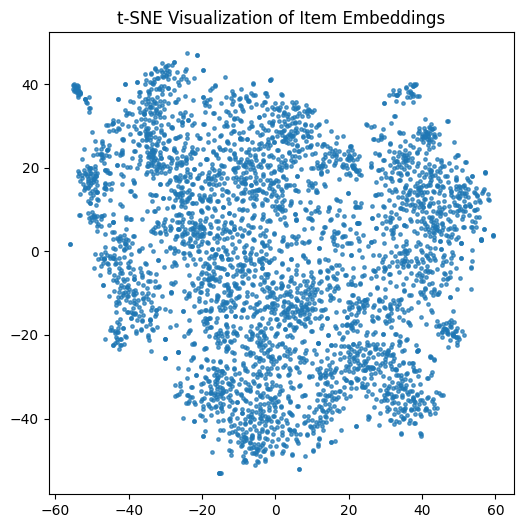

In [29]:
with torch.no_grad():
    users_emb,items_emb=model_sem(adj_norm_torch)

item_embeddings=items_emb.cpu().numpy()
np.save(f"{base_path}/item_embeddings.npy", item_embeddings)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

emb_2d=tsne.fit_transform(item_embeddings)

plt.figure(figsize=(6,6))

plt.scatter(
    emb_2d[:,0],
    emb_2d[:,1],
    s=6,
    alpha=0.7,
    cmap="viridis"
)

plt.title("t-SNE Visualization of Item Embeddings")

plt.savefig(f"{base_path}/tsne_embeddings.png",dpi=300)

plt.show()

# Training Loss

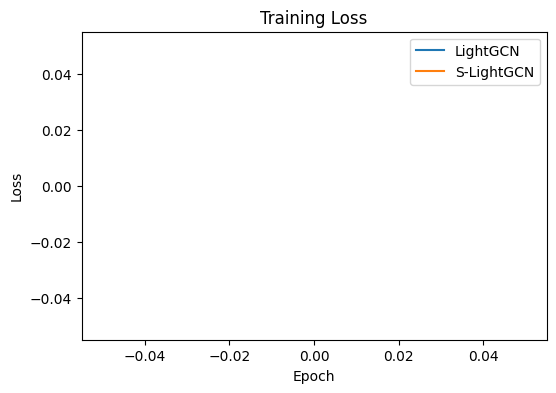

In [30]:
plt.figure(figsize=(6,4))

plt.plot(loss_base, label="LightGCN")
plt.plot(loss_sem, label="S-LightGCN")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()

plt.savefig(f"{base_path}/training_loss.png",dpi=300)

plt.show()

# Alpha senstivity

In [21]:
alpha_path = f"{base_path}/alpha_results.npy"

alphas = [0,0.05,0.1,0.2,0.5]

if os.path.exists(alpha_path):

    print("Loading cached alpha experiment")

    alpha_results = np.load(alpha_path).tolist()

else:

    alpha_results = []

    for a in alphas:

        print("Training with alpha =",a)

        model = SLightGCN(
            n_users,n_items,64,3,text_matrix,alpha=a
        ).to(device)

        train_model(model,epochs=10)

        r = recall_at_k(model,10)

        alpha_results.append(r)

    np.save(alpha_path,alpha_results)

    alpha_json = {
        "alphas": alphas,
        "recall@10": [float(x) for x in alpha_results]
    }

    with open(f"{base_path}/alpha_results.json","w") as f:
        json.dump(alpha_json, f, indent=4)

Training with alpha = 0


Epoch 0 Loss 0.6372448895404588


Epoch 1 Loss 0.42069667466540833


Epoch 2 Loss 0.29705948894148443


Epoch 3 Loss 0.2410238321814964


...

Epoch 5 Loss 0.26896598501436747


Epoch 6 Loss 0.23982622897002234


Epoch 7 Loss 0.2067517396896633


Epoch 8 Loss 0.18544768842298592


Epoch 9 Loss 0.1649985197764724


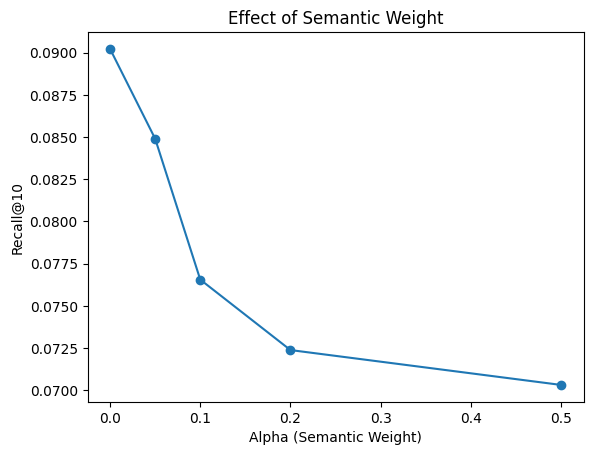

In [22]:
plt.plot(alphas,alpha_results,marker="o")

plt.xlabel("Alpha (Semantic Weight)")
plt.ylabel("Recall@10")
plt.title("Effect of Semantic Weight")

plt.savefig(f"{base_path}/alpha_sensitivity.png",dpi=300)

plt.show()

# Ablation Study

In [ ]:
ablation_path = f"{base_path}/ablation_random.npy"

if os.path.exists(ablation_path):

    recall_random = float(np.load(ablation_path))

else:

    random_text = np.random.normal(size=text_matrix.shape)

    model_random = SLightGCN(
        n_users,n_items,64,3,random_text
    ).to(device)

    train_model(model_random)

    recall_random = recall_at_k(model_random,10)

    np.save(ablation_path,recall_random)

Epoch 0 Loss 0.6160469295373604


Epoch 1 Loss 0.35800468198843854


Epoch 2 Loss 0.19865239912004612


Epoch 3 Loss 0.12834417853337615


Epoch 4 Loss 0.09259521360717603


...

Epoch 25 Loss 0.01697235760876714


Epoch 26 Loss 0.015490967773401471


Epoch 27 Loss 0.015388959872800468


Epoch 28 Loss 0.015458995448564416


Epoch 29 Loss 0.014986177551935412


In [ ]:

experiment_state = {
    "results": results,
    "alpha_results": alpha_results,
    "ablation": {
        "LightGCN": results["LightGCN"]["Recall@10"],
        "RandomText": float(recall_random),
        "SBERT": results["SemanticLightGCN"]["Recall@10"]
    },
    "training_time": {
        "LightGCN": base_training_time,
        "SemanticLightGCN": sem_training_time
    },
    "dataset": metadata
}

with open(f"{base_path}/experiment_summary.json","w") as f:
    json.dump(experiment_state,f,indent=4)